In [33]:
from google.colab import files
uploaded = files.upload()


Saving student_performance_dataset.csv to student_performance_dataset (1).csv


In [34]:
import pandas as pd
df = pd.read_csv('/content/student_performance_dataset.csv')
print(df.shape)
df.head()

(2000, 10)


,Gender,Age,Study_Time,Family_Support,Internet_Access,Previous_Grades,Absences,Extra_Classes,Health_Status,Final_Grade
0,Male,16,1,Yes,Yes,72.8,5,No,3.0,Fail
1,Female,22,1,Yes,Yes,NaN,4,No,5.0,Pass
2,Female,18,1,Yes,Yes,58.1,5,No,5.0,Pass
3,Male,21,2,No,Yes,55.7,5,Yes,2.0,Fail
4,Male,17,2,No,No,76.2,7,Yes,5.0,Pass


In [35]:
print("Shape:", df.shape)                    # (2000, 10)
print("\nData Types:\n", df.dtypes)
print("\nFirst 10 rows:\n", df.head(10))
print("\nStatistical Summary:\n", df.describe(include='all'))

Shape: (2000, 10)

Data Types:
 Gender              object
Age                  int64
Study_Time           int64
Family_Support      object
Internet_Access     object
Previous_Grades    float64
Absences             int64
Extra_Classes       object
Health_Status      float64
Final_Grade         object
dtype: object

First 10 rows:
    Gender  Age  Study_Time Family_Support Internet_Access  Previous_Grades  \
0    Male   16           1            Yes             Yes             72.8   
1  Female   22           1            Yes             Yes              NaN   
2  Female   18           1            Yes             Yes             58.1   
3    Male   21           2             No             Yes             55.7   
4    Male   17           2             No              No             76.2   
5  Female   18           4             No             Yes             75.9   
6    Male   21           3             No             Yes             46.8   
7  Female   18           2            Yes  

In [36]:
print(df.isnull().sum())

Gender              0
Age                 0
Study_Time          0
Family_Support      8
Internet_Access     8
Previous_Grades    13
Absences            0
Extra_Classes       0
Health_Status      12
Final_Grade         0
dtype: int64


In [37]:
print("Duplicates:", df.duplicated().sum())

Duplicates: 15


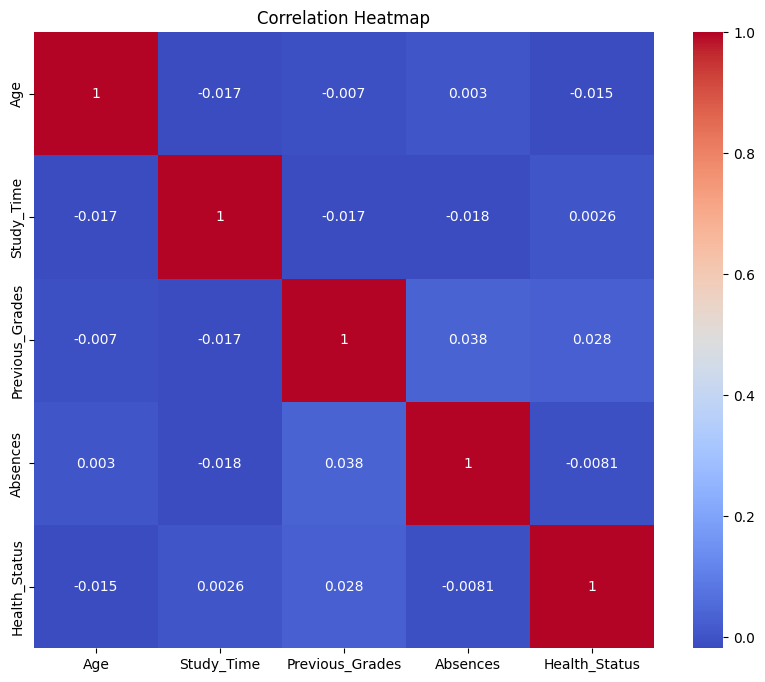

In [38]:
import seaborn as sns
import matplotlib.pyplot as plt

numeric_df = df.select_dtypes(include=['int64', 'float64'])
plt.figure(figsize=(10,8))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

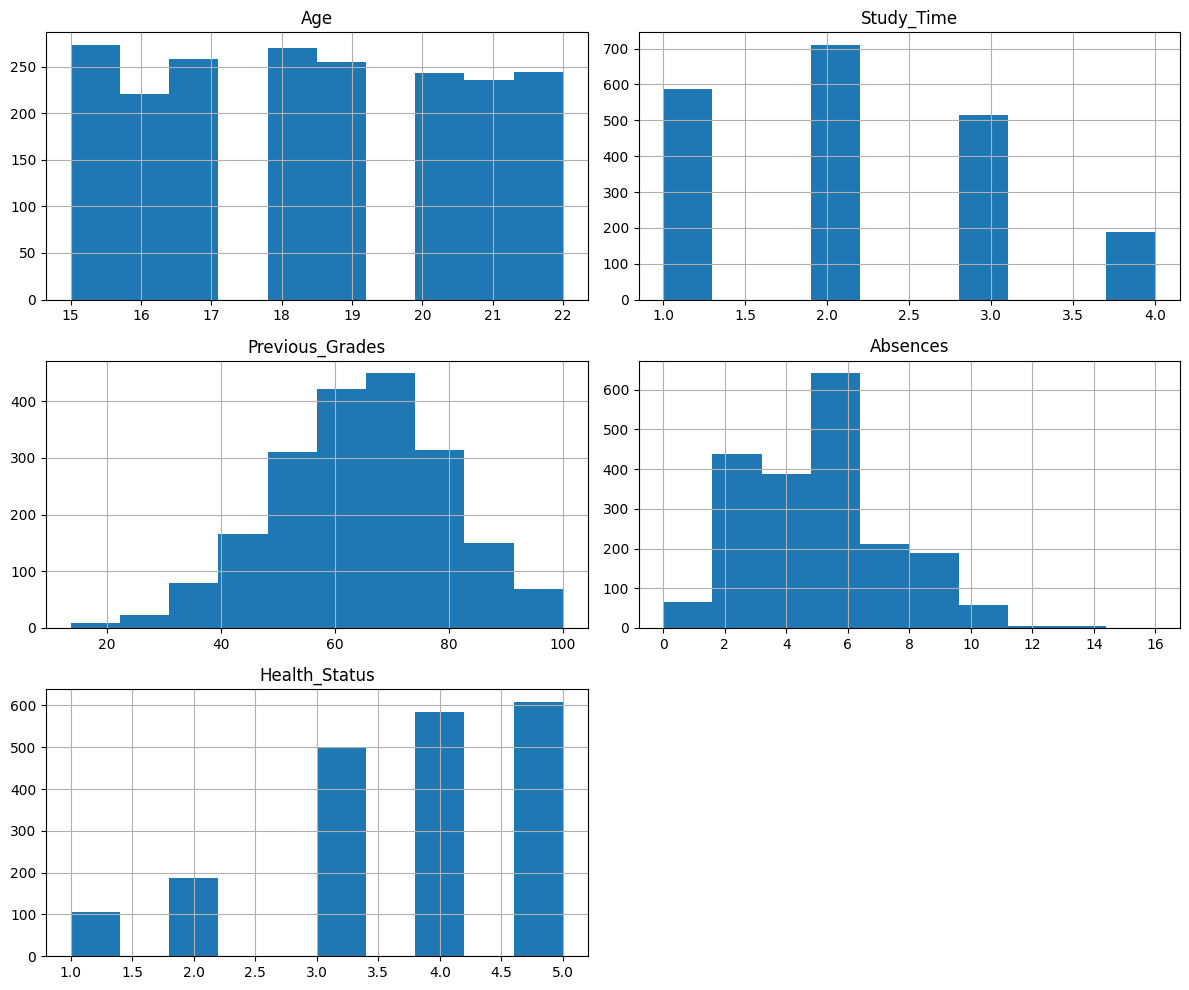

In [39]:
df.hist(figsize=(12,10))
plt.tight_layout()
plt.show()

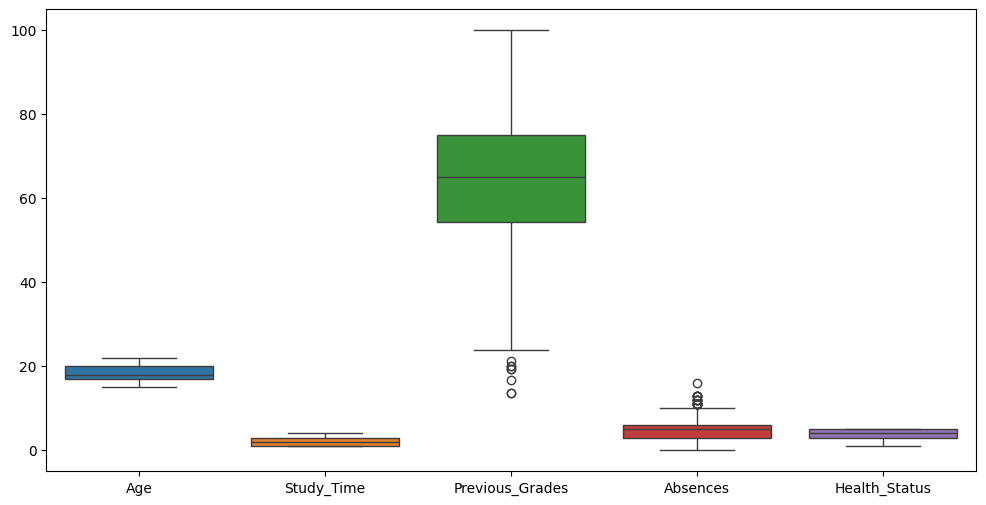

In [40]:
plt.figure(figsize=(12,6))
sns.boxplot(data=df[['Age','Study_Time','Previous_Grades','Absences','Health_Status']])
plt.show()

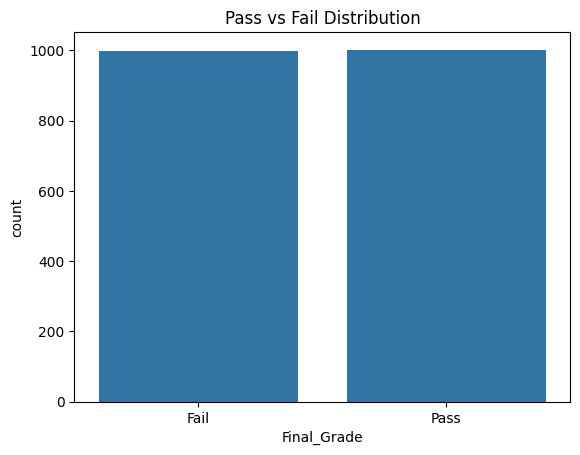

In [41]:
sns.countplot(x='Final_Grade', data=df)
plt.title("Pass vs Fail Distribution")
plt.show()

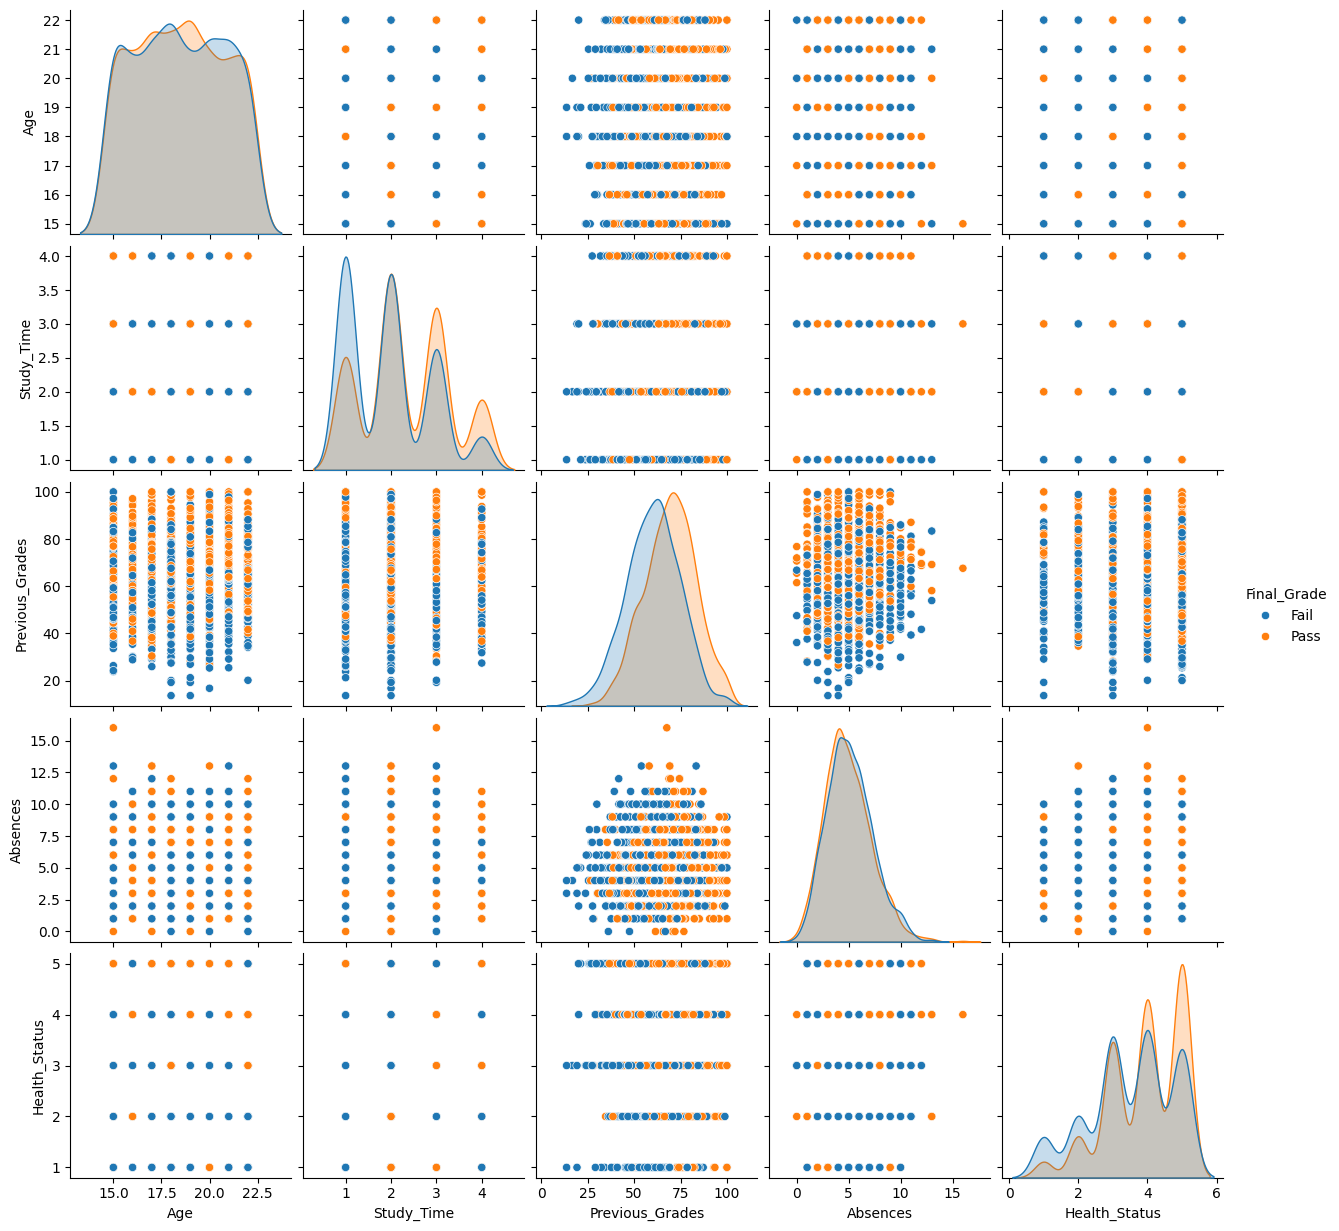

In [42]:
sns.pairplot(df, hue='Final_Grade')
plt.show()

In [21]:

df['Previous_Grades'] = df['Previous_Grades'].fillna(df['Previous_Grades'].median())
df['Health_Status'] = df['Health_Status'].fillna(df['Health_Status'].median())

df['Family_Support'] = df['Family_Support'].fillna(df['Family_Support'].mode()[0])
df['Internet_Access'] = df['Internet_Access'].fillna(df['Internet_Access'].mode()[0])


print(df.isnull().sum())

Gender             0
Age                0
Study_Time         0
Family_Support     0
Internet_Access    0
Previous_Grades    0
Absences           0
Extra_Classes      0
Health_Status      0
Final_Grade        0
dtype: int64


In [22]:
df.drop_duplicates(inplace=True)

In [23]:
def remove_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return df[(df[column] >= lower) & (df[column] <= upper)]

for col in ['Previous_Grades', 'Absences']:
    df = remove_outliers(df, col)

In [24]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
for col in ['Gender', 'Family_Support', 'Internet_Access', 'Extra_Classes', 'Final_Grade']:
    df[col] = le.fit_transform(df[col])

In [25]:
from sklearn.preprocessing import StandardScaler

X = df.drop('Final_Grade', axis=1)
y = df['Final_Grade']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [26]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

In [43]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score

# Models
models = {
    "Logistic Regression": LogisticRegression(),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42)
}

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:,1]

    results[name] = {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": classification_report(y_test, y_pred, output_dict=True)['1']['precision'],
        "Recall": classification_report(y_test, y_pred, output_dict=True)['1']['recall'],
        "F1": classification_report(y_test, y_pred, output_dict=True)['1']['f1-score'],
        "ROC-AUC": roc_auc_score(y_test, y_prob)
    }
    print(f"\n{name}:")
    print(classification_report(y_test, y_pred))


Logistic Regression:
              precision    recall  f1-score   support

           0       0.75      0.77      0.76       195
           1       0.77      0.75      0.76       196

    accuracy                           0.76       391
   macro avg       0.76      0.76      0.76       391
weighted avg       0.76      0.76      0.76       391


Decision Tree:
              precision    recall  f1-score   support

           0       0.66      0.65      0.65       195
           1       0.66      0.66      0.66       196

    accuracy                           0.66       391
   macro avg       0.66      0.66      0.66       391
weighted avg       0.66      0.66      0.66       391


Random Forest:
              precision    recall  f1-score   support

           0       0.73      0.73      0.73       195
           1       0.73      0.73      0.73       196

    accuracy                           0.73       391
   macro avg       0.73      0.73      0.73       391
weighted avg       0

In [44]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [5, 10, 15, None],
    'min_samples_split': [2, 5, 10]
}

grid = GridSearchCV(RandomForestClassifier(random_state=42),
                    param_grid, cv=5, scoring='f1', n_jobs=-1)
grid.fit(X_train, y_train)

print("Best Params:", grid.best_params_)
best_model = grid.best_estimator_

Best Params: {'max_depth': None, 'min_samples_split': 10, 'n_estimators': 100}


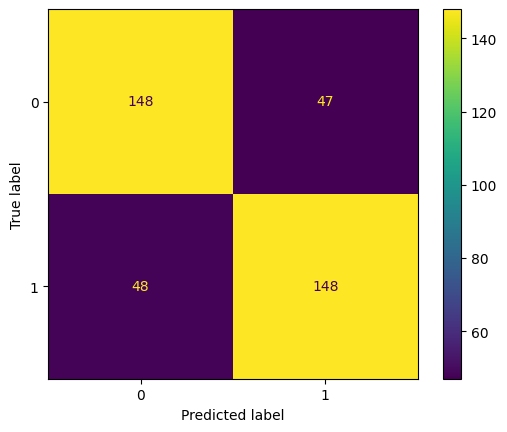

In [29]:
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_estimator(best_model, X_test, y_test)
plt.show()

Previous_Grades    0.316495
Family_Support     0.149699
Extra_Classes      0.148426
Health_Status      0.089130
Study_Time         0.087081
Absences           0.086064
Age                0.074051
Internet_Access    0.027553
Gender             0.021500
dtype: float64


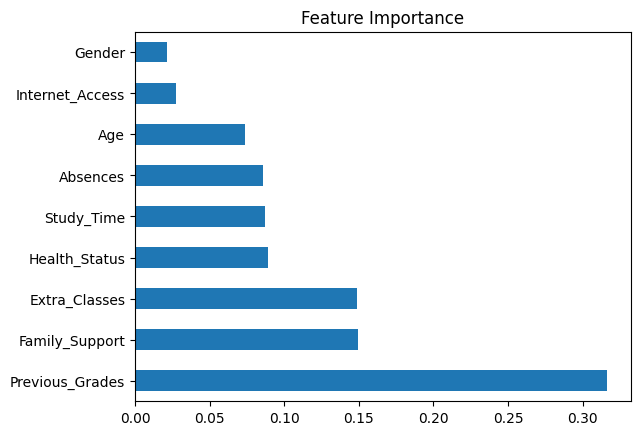

In [30]:
importances = best_model.feature_importances_
feat_imp = pd.Series(importances, index=X.columns).sort_values(ascending=False)
print(feat_imp)

# Plot
feat_imp.plot(kind='barh')
plt.title("Feature Importance")
plt.show()